# 3. Association Rules

**Apriori** was selected given that **the dataset is not large in scale**, making its computational **cost manageable**, and **the algorithm is conceptually simple and highly transparent**. 
Compared with FP-Growth, Apriori provides **more interpretable intermediate results**, which makes it more suitable for reporting and presenting frequent itemsets and association rules.
## 3.1 Socio-economic Patterns & Insurance Type
### 3.1.1 Frequent Itemsets

In [75]:
# Retain the samples aged 18 or above
import pandas as pd
import numpy as np

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

nhanes_clean = pd.read_csv("/Users/sherrywang/Desktop/Projects/Dataset/nhanes_clean.csv")
nhanes_clean_adult = nhanes_clean[nhanes_clean['age'] >= 18].copy()
nhanes_clean_adult.to_csv("nhanes_clean_adult.csv")
nhanes_clean_adult.to_pickle("nhanes_clean_adult.pkl")
print(nhanes_clean_adult.shape)

(8153, 21)


In [76]:
#Socio-economic → Insurance type

# Numeric data discretization

# Income poverty ratio discretization
nhanes_clean_adult['income_poverty_ratio_bin'] = pd.cut(
    nhanes_clean_adult['income_poverty_ratio'],
    bins = [0, 1, 2, 4, np.inf],
    labels = ['<=1 (Below poverty line)', '1-2', '2-4', '>4']
)

# Age discretization
nhanes_clean_adult['age_bin'] = pd.cut(
    nhanes_clean_adult['age'],
    bins= [18,30,45,60,80],
    labels= ['18-30', '31-45', '46-60', '61-80'],
    include_lowest=True
)
    
# Select categorical Socio-economic features
soci_cols = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type'
]
nhanes_fp = nhanes_clean_adult[soci_cols].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_fp
    .apply(lambda r: [f"{c}={r[c]}" for c in nhanes_fp.columns if pd.notna(r[c])], axis=1)
    .tolist()
)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_tf = pd.DataFrame(te_ary, columns = te.columns_)

In [46]:
# Run Apriori algorithm
freq_items = apriori(nhanes_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
92,0.320005,"(gender=Female, race=Non-Hispanic White)"
59,0.272906,"(age_bin=61-80, race=Non-Hispanic White)"
102,0.256961,"(race=Non-Hispanic White, gender=Male)"
108,0.232920,"(income_poverty_ratio_bin=2-4, race=Non-Hispanic White)"
116,0.232430,"(insurance_type=Private only, race=Non-Hispanic White)"
67,0.224580,"(education=College graduate or above, race=Non-Hispanic White)"
51,0.222495,"(gender=Female, age_bin=61-80)"
85,0.221391,"(gender=Female, income_poverty_ratio_bin=2-4)"
90,0.220164,"(gender=Female, insurance_type=Public only)"
114,0.207163,"(income_poverty_ratio_bin=>4, race=Non-Hispanic White)"


**Key observation:**

The most frequent itemsets combine **Non-Hispanic White race** with:
  - Female gender,
  - Older age (61–80),
  - Higher income-to-poverty ratio (2–4 or >4),
  - Private Insurance. :contentReference[oaicite:0]{index=0}  

This immediately shows that in our adult NHANES sample, **older, White, relatively better-off individuals are well covered**.

### 3.1.2 : Rules with Insurance Type as Consequent

In [47]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter insurance type as the consequent
rules_insurance = rules[rules['consequents'].astype(str).str.contains('insurance_type')]
rules_insurance = rules_insurance.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_insurance[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)


,antecedents,consequents,support,confidence,lift,kulc,ir
586,"(gender=Female, age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.063903,0.423922,2.695971,0.415159,0.026633
593,"(age_bin=61-80, race=Non-Hispanic White)","(gender=Female, insurance_type=Both)",0.063903,0.234157,2.629593,0.475894,0.616872
316,"(age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.110879,0.406292,2.583853,0.555720,0.362274
194,"(age_bin=61-80, education=College graduate or above)",(insurance_type=Both),0.052005,0.401135,2.551058,0.365934,0.117493
136,"(income_poverty_ratio_bin=>4, age_bin=31-45)",(insurance_type=Private only),0.052864,0.874239,2.440984,0.510921,0.813883
165,"(income_poverty_ratio_bin=>4, age_bin=46-60)",(insurance_type=Private only),0.059119,0.866906,2.420510,0.515987,0.789579
653,"(income_poverty_ratio_bin=>4, gender=Female)","(education=College graduate or above, insurance_type=Private only)",0.059978,0.418664,2.393668,0.380791,0.122565
724,(income_poverty_ratio_bin=>4),"(education=College graduate or above, insurance_type=Private only, race=Non-Hispanic White)",0.080216,0.286842,2.374237,0.475401,0.495979
589,"(gender=Female, age_bin=61-80)","(insurance_type=Both, race=Non-Hispanic White)",0.063903,0.287211,2.358135,0.405942,0.359143
112,"(age_bin=31-45, education=College graduate or above)",(insurance_type=Private only),0.068318,0.816716,2.280370,0.503734,0.734975


In [62]:
# Filter rules meet the criteria: support > 0.05, confidence > 0.4 and lift > 1.6
rules_insurance = rules[
    (rules['consequents'].astype(str).str.contains('insurance_type')) &
    (rules['support'] > 0.05) &
    ((rules['confidence'] > 0.4) & (rules['lift'] > 1.6)) &
     (rules['consequents'].apply(lambda s: all('insurance_type' in x for x in s)))
].sort_values('lift', ascending=False)

rules_insurance[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(15)

,antecedents,consequents,support,confidence,lift,kulc,ir
586,"(gender=Female, age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.063903,0.423922,2.695971,0.415159,0.026633
316,"(age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.110879,0.406292,2.583853,0.555720,0.362274
194,"(age_bin=61-80, education=College graduate or above)",(insurance_type=Both),0.052005,0.401135,2.551058,0.365934,0.117493
136,"(income_poverty_ratio_bin=>4, age_bin=31-45)",(insurance_type=Private only),0.052864,0.874239,2.440984,0.510921,0.813883
165,"(income_poverty_ratio_bin=>4, age_bin=46-60)",(insurance_type=Private only),0.059119,0.866906,2.420510,0.515987,0.789579
112,"(age_bin=31-45, education=College graduate or above)",(insurance_type=Private only),0.068318,0.816716,2.280370,0.503734,0.734975
149,"(education=College graduate or above, age_bin=46-60)",(insurance_type=Private only),0.053968,0.791367,2.209594,0.471026,0.778656
143,"(age_bin=31-45, race=Non-Hispanic White)",(insurance_type=Private only),0.069668,0.664327,1.854884,0.429424,0.643904
650,"(income_poverty_ratio_bin=>4, gender=Female, education=College graduate or above)",(insurance_type=Private only),0.059978,0.655496,1.830226,0.411481,0.684293
178,"(race=Non-Hispanic White, age_bin=46-60)",(insurance_type=Private only),0.077885,0.647299,1.807338,0.432382,0.593693


**1. Rules leading to “Both” (dual coverage)**  
Rules such as 'age 61–80 & Non-Hispanic White → Both' show **lift ≈ 2.6–2.7** and moderate support.
**Insight**: Dual coverage (“Both”) is mainly concentrated among **older adults** who combine Medicare eligibility with private supplemental plans.  
Because **Medicare automatically covers individuals aged 65 and above**, older adults naturally exhibit higher rates of dual (public + private) coverage, creating a clear coverage advantage in this age group.  

**2. Rules leading to “Private only”**  
Strong rules like 'income > 4× poverty line & age 31–60 → Private only', 'college graduate & age 31–60 → Private only' have lift > 2.2 and confidence often > 0.8.  
**Insight**: **Middle-aged adults** who are **high-income or college-educated** overwhelmingly rely on private insurance.  
These groups benefit from **stable employment and employer-sponsored plans**, showing a clear socioeconomic gradient in private coverage access.

**3. Rules leading to “Public only”**    
Patterns like 'below poverty line & female → Public only' or 'below poverty line → Public only' show lift ≈ 1.6–1.7.    
**Insight**:**Low-income population** highly depend on **public insurance only**, and almost never appear in high-lift rules for private coverage.  
This highlights a **vulnerability** where **poverty** restrict access to private plans.   

## 3.2 Multi-Domain Determinants & Hypertension
### 3.2.1 Frequent Itemsets

In [30]:
# Hypertension Exploration
def hypertension_stage(row):
    sbp = row['sbp']
    dbp = row['dbp']

    # Normal（incl. Elevated）
    if sbp < 130 and dbp < 80:
        return "Normal"

    # Stage 1 Hypertension
    elif (130 <= sbp < 140) or (80 <= dbp < 90):
        return "Stage 1"

    # Stage 2 Hypertension
    elif sbp >= 140 or dbp >= 90:
        return "Stage 2"

    else:
        return "Undefined"
        
nhanes_clean_adult['htn_stage'] = nhanes_clean_adult.apply(hypertension_stage, axis=1)

# Numeric data discretization
# BMI discretization
nhanes_clean_adult['bmi_bin'] = pd.cut(
    nhanes_clean_adult['bmi'],       
    bins=[0, 25, 30, np.inf],
    labels=['Normal', 'Overweight', 'Obesity']
)

# Sleep (hours) discretization
nhanes_clean_adult['sleep_bin'] = pd.cut(
    nhanes_clean_adult['sleep_hours'],   
    bins=[0, 6, 8, np.inf],
    labels=['Short (<6h)', 'Normal (6-8h)', 'Long (>8h)']
)

# Select Multi-domain Determinants
determinant_features = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type',
    'bmi_bin',
    'sleep_bin',
    'smoking_current',
    'htn_stage'
]
nhanes_health_fp = nhanes_clean_adult[determinant_features].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_health_fp
    .apply(
        lambda r: [
            f"{c}={r[c]}" 
            for c in nhanes_health_fp.columns 
            if pd.notna(r[c])
        ],
        axis=1
    )
    .tolist()
)


te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_health_tf = pd.DataFrame(te_ary, columns = te.columns_)
nhanes_health_tf

# Run Apriori algorithm
freq_items = apriori(nhanes_health_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
250,0.418987,"(smoking_current=No, htn_stage=Normal)"
245,0.386851,"(race=Non-Hispanic White, htn_stage=Normal)"
201,0.384644,"(gender=Female, htn_stage=Normal)"
217,0.360849,"(gender=Female, smoking_current=No)"
248,0.352508,"(sleep_bin=Normal (6-8h), htn_stage=Normal)"
142,0.342083,"(bmi_bin=Overweight, htn_stage=Normal)"
317,0.324666,"(race=Non-Hispanic White, smoking_current=No)"
212,0.320005,"(gender=Female, race=Non-Hispanic White)"
322,0.318901,"(sleep_bin=Normal (6-8h), smoking_current=No)"
315,0.313995,"(sleep_bin=Normal (6-8h), race=Non-Hispanic White)"


The **most frequent itemsets** consistently combine "Normal blood pressure" with **healthier lifestyle** or **demographic traits**.
Specifically, the top itemsets pair Normal BP with:
- non-smoking status
- being female
- healthy sleep duration (6-8 hours)
- White race

This pattern shows that in our adult NHANES sample often share other healthy traits-such as not smoking, getting enough sleep, and belonging to generally advantaged demographic groups (female, Non-Hispanic White). 
These factors commonly appear together and form a cluster of low-risk health characteristics.

### 3.2.2 Rules for Hypertension Stages

In [31]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter diabete risk as the consequent
rules_htn = rules[
    rules['consequents'].astype(str).str.contains('htn_stage')
].copy()
rules_htn = rules_htn.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_htn[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
3742,"(age_bin=61-80, race=Non-Hispanic White)","(insurance_type=Both, htn_stage=Normal)",0.063903,0.234157,2.555669,0.465807,0.603019
2962,"(age_bin=31-45, education=College graduate or above)","(insurance_type=Private only, htn_stage=Normal)",0.053477,0.639296,2.493867,0.423954,0.602740
3745,(insurance_type=Both),"(age_bin=61-80, race=Non-Hispanic White, htn_stage=Normal)",0.063903,0.406396,2.493114,0.399210,0.022488
5579,"(education=College graduate or above, insurance_type=Private only)","(income_poverty_ratio_bin=>4, htn_stage=Normal)",0.079357,0.453717,2.451393,0.441239,0.036276
2970,(insurance_type=Private only),"(age_bin=31-45, education=College graduate or above, htn_stage=Normal)",0.053477,0.149315,2.318792,0.489896,0.795945
3746,(age_bin=61-80),"(insurance_type=Both, race=Non-Hispanic White, htn_stage=Normal)",0.063903,0.157164,2.209244,0.527720,0.810611
5582,(income_poverty_ratio_bin=>4),"(education=College graduate or above, insurance_type=Private only, htn_stage=Normal)",0.079357,0.283772,2.188829,0.447941,0.454647
3740,"(insurance_type=Both, race=Non-Hispanic White)","(age_bin=61-80, htn_stage=Normal)",0.063903,0.524673,2.186941,0.395516,0.396623
5623,(education=College graduate or above),"(income_poverty_ratio_bin=>4, smoking_current=No, htn_stage=Normal)",0.089415,0.277714,2.164632,0.487328,0.536710
4242,"(education=College graduate or above, bmi_bin=Overweight)","(income_poverty_ratio_bin=>4, htn_stage=Normal)",0.056421,0.398268,2.151811,0.351553,0.160617


In [32]:
# Filter rules meet the criteria: support > 0.03, confidence > 0.2 and lift > 1.3
rules_htn = rules[
    (rules['support'] > 0.03) &
    (rules['confidence'] > 0.2) &
    (rules['lift'] > 1.3) &
    (rules['consequents'].apply(lambda s: len(s) == 1)) &
    (rules['consequents'].apply(lambda s: list(s)[0].startswith('htn_stage')))
].sort_values('lift', ascending=False)

rules_htn[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
1402,"(bmi_bin=Obesity, race=Non-Hispanic White)",(htn_stage=Stage 1),0.063535,0.329098,1.463794,0.305847,0.089650
1412,"(bmi_bin=Obesity, smoking_current=No)",(htn_stage=Stage 1),0.062799,0.324051,1.441345,0.301687,0.087211
100,(bmi_bin=Obesity),(htn_stage=Stage 1),0.107200,0.323464,1.438736,0.400139,0.237367
1408,"(sleep_bin=Normal (6-8h), bmi_bin=Obesity)",(htn_stage=Stage 1),0.053845,0.318347,1.415974,0.278922,0.163722
2866,"(age_bin=18-30, bmi_bin=Overweight, smoking_current=No)",(htn_stage=Normal),0.052251,0.940397,1.386950,0.508730,0.913591
322,"(age_bin=18-30, bmi_bin=Overweight)",(htn_stage=Normal),0.067705,0.940375,1.386917,0.520115,0.888190
310,"(age_bin=18-30, bmi_bin=Normal)",(htn_stage=Normal),0.054336,0.911523,1.344364,0.495830,0.905044
332,"(age_bin=18-30, gender=Female)",(htn_stage=Normal),0.082056,0.910204,1.342419,0.515612,0.856811
2878,"(age_bin=18-30, gender=Female, smoking_current=No)",(htn_stage=Normal),0.071630,0.908243,1.339526,0.506943,0.874351
2930,"(age_bin=31-45, gender=Female, bmi_bin=Overweight)",(htn_stage=Normal),0.050902,0.908096,1.339311,0.491584,0.910413


In [33]:
htn = [
    'htn_stage=Stage 1',
    'htn_stage=Stage 2'
]

rules_htn = (
    rules[
        (rules['support'] > 0.03) &
        (rules['confidence'] > 0.1) &
        (rules['lift'] > 1.1) &
        (rules['consequents'].apply(lambda s: len(s) == 1)) &
        (rules['consequents'].apply(lambda s: list(s)[0] in htn))
    ]
    .sort_values('lift', ascending=False)
)

rules_htn[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
58,(age_bin=61-80),(htn_stage=Stage 2),0.059242,0.145701,1.499878,0.377775,0.696192
1402,"(bmi_bin=Obesity, race=Non-Hispanic White)",(htn_stage=Stage 1),0.063535,0.329098,1.463794,0.305847,0.089650
1412,"(bmi_bin=Obesity, smoking_current=No)",(htn_stage=Stage 1),0.062799,0.324051,1.441345,0.301687,0.087211
100,(bmi_bin=Obesity),(htn_stage=Stage 1),0.107200,0.323464,1.438736,0.400139,0.237367
1408,"(sleep_bin=Normal (6-8h), bmi_bin=Obesity)",(htn_stage=Stage 1),0.053845,0.318347,1.415974,0.278922,0.163722
1336,"(bmi_bin=Obesity, gender=Female)",(htn_stage=Stage 1),0.059119,0.291239,1.295400,0.277098,0.059215
38,(age_bin=46-60),(htn_stage=Stage 1),0.057770,0.271470,1.207470,0.264213,0.031644
984,"(age_bin=61-80, smoking_current=No)",(htn_stage=Stage 1),0.056789,0.268873,1.195922,0.260732,0.035899
974,"(age_bin=61-80, race=Non-Hispanic White)",(htn_stage=Stage 1),0.073347,0.268764,1.195435,0.297503,0.113295
2662,"(income_poverty_ratio_bin=>4, race=Non-Hispanic White)",(htn_stage=Stage 1),0.055562,0.268206,1.192954,0.257671,0.046921


**1. Risk-increasing patterns**  
Rules such as 'bmi_bin=Obesity & race=Non-Hispanic White → htn_stage=Stage 1' show lift ≈ 1.5.
**Obesity alone** already maps to **Stage 1** with confidence ≈ 0.32, making it one of the earliest detectable risk markers.  
**Insight**: **Obesity acts as a key entry point into hypertension**, elevating Stage 1 risk even before age becomes a major driver. This suggests that early **weight-management interventions** could substantially delay or prevent the transition from Normal BP to Stage 1.

**2. Age-driven patterns**  
- **Older age groups** (e.g., age_bin=61–80) appear in the strongest rules for **Stage 2**, showing the highest lift among all Stage-2 associations.
- **Young age groups** such as age_bin=18–30 who are overweight still overwhelmingly maintain normal blood pressure. With a confidence of ~94%, this is one of **the strongest protective patterns** in the dataset.  
**Insight**: The rules capture a clear physiological gradient: **young age protects, obesity pushes individuals into Stage 1, and aging ultimately drives progression to Stage 2**.

# 4. Classification

Three classification models—**Decision Tree**, **Random Forest**, and **XGBoost**—were selected to provide a balanced comparison between interpretability and predictive performance.  

**Decision Tree**  
- **High interpretability**: produces clear **if–then structures** that reveal explicit decision rules.
- **Rule-capturing ability**: effective for **datasets with strong hierarchical or threshold patterns** (e.g., age or BMI splits in hypertension).
- **Lightweight baseline**: fast to train, easy to visualize, and ideal as an initial **benchmark model**.

**Random Forest**  
- **Robust against overfitting**: **aggregates** multiple decorrelated decision trees via **bagging**, greatly **improving stability** **under noisy or imbalanced data**.
- **Strong generalization**: suited for **multi-class prediction** with many variables.
- **Nonlinear modeling ability**: automatically captures **interaction effects and complex nonlinear patterns** that a single tree may miss.

**XGBoost**  
- **High predictive power**: **optimized boosted tree ensembles** that excel on structured tabular data.
- **Captures complex interactions**: models **nonlinear effects** and deep feature interactions through **sequential boosting**.
- **Improved minority-class performance**: often enhances **recall and F1-scores** for **underrepresented classes**, which is valuable in multi-class health classification.

## 4.1 Classification for Insurance Type

### 4.1.1 Baseline Models - Decision Tree, Random Forest, XGBoost

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    f1_score,
    make_scorer
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

#The insurance classification model initially built using the baseline set of 14 features
nhanes_clean_adult_add = pd.read_csv("nhanes_clean_adult_add.csv")

ins_feature_cols_base = [
    "age",
    "gender",
    "race",
    "education",
    "income_poverty_ratio",
    "smoking_current",
    "diabetes_self_report",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours",
]

target_ins = "insurance_type"

categorical_ins_base = [
    "gender", "race", "education",
    "smoking_current", "diabetes_self_report",
]

numeric_ins_base = [
    "age", "income_poverty_ratio",
    "bmi", "sbp", "dbp", "a1c", "sleep_hours",
]

preprocess_ins_base = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_ins_base),
        ("num", "passthrough", numeric_ins_base),
    ]
)

X_ins_base = nhanes_clean_adult_add[ins_feature_cols_base].copy()
y_ins_base = nhanes_clean_adult_add[target_ins].copy()

data_ins_base = pd.concat([X_ins_base, y_ins_base], axis=1).dropna(
    subset=ins_feature_cols_base + [target_ins]
)
X_ins_base = data_ins_base[ins_feature_cols_base]
y_ins_base = data_ins_base[target_ins]

# y encode
le_ins_base = LabelEncoder()
y_ins_base_enc = le_ins_base.fit_transform(y_ins_base)

# Train/Test Split
X_ins_base_train, X_ins_base_test, y_ins_base_train, y_ins_base_test = train_test_split(
    X_ins_base,
    y_ins_base_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_ins_base_enc,
)

# StratifiedKFold
cv_ins_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_ins = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion="entropy", max_depth=5,
        min_samples_split=50, min_samples_leaf=10,
        random_state=42
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=400, max_depth=None,
        min_samples_split=5, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, objective="multi:softprob",
        eval_metric="mlogloss", random_state=42
    )
}

scoring_cv_base = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "recall_weighted": "recall_weighted",
    "f1_macro": "f1_macro",
}

for name, clf in models_ins.items():
    pipe_base = Pipeline([
        ("preprocess", preprocess_ins_base),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf),
    ])

    cv_res_base = cross_validate(
        pipe_base,
        X_ins_base_train,
        y_ins_base_train,
        cv=cv_ins_base,
        scoring=scoring_cv_base,
        n_jobs=1,
        return_train_score=False,
    )

    print(f"\n=== Insurance {name} (baseline) ===")
    print("5-fold Accuracy per fold:", cv_res_base["test_accuracy"])
    print("5-fold Macro Recall per fold:", cv_res_base["test_recall_macro"])
    print("5-fold F1-macro per fold:", cv_res_base["test_f1_macro"])
    print("Mean Accuracy:", cv_res_base["test_accuracy"].mean())
    print("Mean Macro Recall:", cv_res_base["test_recall_macro"].mean())
    print("Mean F1-macro:", cv_res_base["test_f1_macro"].mean())


=== Insurance Decision_Tree (baseline) ===
5-fold Accuracy per fold: [0.52260536 0.52337165 0.53911043 0.49846626 0.52300613]
5-fold Macro Recall per fold: [0.49714417 0.55069747 0.50606466 0.49415156 0.49340032]
5-fold F1-macro per fold: [0.45164768 0.44772236 0.44418276 0.42343628 0.43357231]
Mean Accuracy: 0.5213119667160285
Mean Macro Recall: 0.5082916355636635
Mean F1-macro: 0.4401122771716165

=== Insurance Random_Forest (baseline) ===
5-fold Accuracy per fold: [0.61149425 0.61992337 0.62806748 0.61886503 0.62116564]
5-fold Macro Recall per fold: [0.46689334 0.49239247 0.45318512 0.43597733 0.42249779]
5-fold F1-macro per fold: [0.48452714 0.51582247 0.4623569  0.44524399 0.42519307]
Mean Accuracy: 0.619903156806055
Mean Macro Recall: 0.45418921110655575
Mean F1-macro: 0.4666287155512941

=== Insurance XGBoost (baseline) ===
5-fold Accuracy per fold: [0.61226054 0.6137931  0.62883436 0.6357362  0.60966258]
5-fold Macro Recall per fold: [0.46701043 0.48304579 0.43173658 0.4719938

### 4.1.2 Models with More Socio-economic Features and  - Decision Tree, Random Forest, XGBoost

In [87]:
# To improve the model accurary, considering adding more soci-economic features
# marital_status (DMDMARTZ) from DEMO_L.xpt
# household_size (DMDHHSIZ) from DEMO_L.xpt
# is_employed (OCQ180) from OCQ_L.xpt

path = "/Users/sherrywang/Desktop/Data_Mining/Project/data-mining-project-starter/data/raw/"
demo = pd.read_sas(path + "DEMO_L.xpt")
ocq  = pd.read_sas(path + "OCQ_L.xpt")

demo_sub = demo[['SEQN', 'DMDMARTZ', 'DMDHHSIZ']].copy()

demo_sub = demo_sub.rename(columns={
    'DMDMARTZ': 'marital_status',
    'DMDHHSIZ': 'household_size'
})

# Marital_status Mapping
marital_map = {
    1: "Married / living with partner",
    2: "Widowed / divorced / separated",
    3: "Never married",
    77: None,
    99: None
}
demo_sub['marital_status'] = demo_sub['marital_status'].map(marital_map)

#Is_employed Mapping
ocq_sub = ocq[['SEQN', 'OCQ180']].copy()
ocq_sub = ocq_sub.rename(columns={'OCQ180': 'hours_worked_last_week'})
ocq_sub['hours_worked_last_week'] = ocq_sub['hours_worked_last_week'].replace(
    {77777: np.nan, 99999: np.nan}
)

# Simple employment indicator
ocq_sub['is_employed'] = ocq_sub['hours_worked_last_week'].apply(
    lambda x: "Yes" if pd.notna(x) and x > 0 else "No"
)

# Merge as the soci_raw

soci_raw = (
    demo_sub
    .merge(ocq_sub, on='SEQN', how='left')
)
soci_raw = soci_raw.rename(columns={'SEQN': 'id'})

soci_raw.head()

,id,marital_status,household_size,hours_worked_last_week,is_employed
0,130378.0,Married / living with partner,4.0,40.0,Yes
1,130379.0,Married / living with partner,2.0,32.0,Yes
2,130380.0,Married / living with partner,7.0,8.0,Yes
3,130381.0,NaN,2.0,NaN,NaN
4,130382.0,NaN,4.0,NaN,NaN


In [88]:
nhanes_clean_adult = pd.read_csv("nhanes_clean_adult.csv")

nhanes_clean_adult_add = nhanes_clean_adult.copy()
nhanes_clean_adult_add = nhanes_clean_adult_add.merge(soci_raw, on='id', how='left')
print('Missing Percentage by Variable')
print(nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].isna().mean().sort_values(ascending=False))

print('\nVariable Types (dtypes)')
print(nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].dtypes)

nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].describe(include='all').round(2)

Missing Percentage by Variable
marital_status    0.045382
household_size    0.000000
is_employed       0.000000
dtype: float64

Variable Types (dtypes)
marital_status     object
household_size    float64
is_employed        object
dtype: object


,marital_status,household_size,is_employed
count,7783,8153.00,8153
unique,3,NaN,2
top,Married / living with partner,NaN,Yes
freq,4136,NaN,4118
mean,NaN,2.62,NaN
std,NaN,1.49,NaN
min,NaN,1.00,NaN
25%,NaN,2.00,NaN
50%,NaN,2.00,NaN
75%,NaN,4.00,NaN


In [89]:
# Handling missing values
nhanes_clean_adult_add['marital_status'] = (
    nhanes_clean_adult_add['marital_status']
        .astype('string')
        .str.strip()
        .fillna("Unknown")
)
print('Missing Percentage by Variable')
print(nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].isna().mean().sort_values(ascending=False))
nhanes_clean_adult_add = nhanes_clean_adult_add.drop(columns=['hours_worked_last_week'], errors='ignore')
nhanes_clean_adult_add = nhanes_clean_adult_add.loc[:, ~nhanes_clean_adult_add.columns.str.contains('^Unnamed')]
nhanes_clean_adult_add.to_csv("nhanes_clean_adult_add.csv", index=False)

Missing Percentage by Variable
marital_status    0.0
household_size    0.0
is_employed       0.0
dtype: float64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ins_feature_cols = [
    "age",
    "gender",
    "race",
    "education",
    "income_poverty_ratio",
    "marital_status",
    "household_size",
    "is_employed",
    "smoking_current",
    "diabetes_self_report",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours"
]
target_ins = "insurance_type"

categorical_ins = [
    "gender", "race", "education", "marital_status",
    "is_employed", "smoking_current", "diabetes_self_report"
]
numeric_ins = [
    "age", "income_poverty_ratio", "household_size",
    "bmi", "sbp", "dbp", "a1c", "sleep_hours"
]

#ColumnTransformer + OneHot
preprocess_ins = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_ins),
        ("num", "passthrough", numeric_ins),
    ]
)

In [6]:
# Train/Test Split
X_ins = nhanes_clean_adult_add[ins_feature_cols].copy()
y_ins = nhanes_clean_adult_add[target_ins].copy()


data_ins = pd.concat([X_ins, y_ins], axis=1).dropna(subset=ins_feature_cols + [target_ins])
X_ins = data_ins[ins_feature_cols]
y_ins = data_ins[target_ins]

# LabelEncoder transfer y from characters to integer 
le_ins = LabelEncoder()
y_ins_encoded = le_ins.fit_transform(y_ins)

X_ins_train, X_ins_test, y_ins_train, y_ins_test = train_test_split(
    X_ins,
    y_ins_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_ins_encoded,
)

#StratifiedKFold Cross Validation
cv_ins = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
# Baseline Model

models_ins = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion="entropy", max_depth=5,
        min_samples_split=50, min_samples_leaf=10,
        random_state=42
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=400, max_depth=None,
        min_samples_split=5, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=2
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    )
}

scoring_cv = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "recall_weighted": "recall_weighted",
    "f1_macro": "f1_macro",
}

print("BASELINE CV PERFORMANCE")
baseline_scores = {}

for name, clf in models_ins.items():
    pipe = Pipeline([
        ("preprocess", preprocess_ins),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf),
    ])

    cv_res = cross_validate(
        pipe, X_ins_train, y_ins_train,
        cv=cv_ins, scoring=scoring_cv, n_jobs=2,
        return_train_score=False
    )

    acc_mean = cv_res["test_accuracy"].mean()
    rec_mean = cv_res["test_recall_macro"].mean()
    f1_mean  = cv_res["test_f1_macro"].mean()

    baseline_scores[name] = {
        "accuracy_cv": acc_mean,
        "recall_macro_cv": rec_mean,
        "f1_macro_cv": f1_mean,
    }

    print(f"\nInsurance {name} (baseline)")
    print("5-fold Accuracy per fold:", cv_res["test_accuracy"])
    print("5-fold Macro Recall per fold:", cv_res["test_recall_macro"])
    print("5-fold F1-macro per fold:", cv_res["test_f1_macro"])
    print("Mean Accuracy:", acc_mean)
    print("Mean Macro Recall:", rec_mean)
    print("Mean F1-macro:", f1_mean)



# GridSearchCV with F1-macro as main metric

param_grids = {
    "Decision_Tree": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [3, 5, 10, None],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "Random_Forest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5],
        "clf__max_features": ["sqrt", "log2"],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
    }
}

f1_macro_scorer = make_scorer(f1_score, average="macro")

scoring_multi = {
    "f1_macro": f1_macro_scorer,
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
}

best_models_ins = {}
tuned_scores = {}

print("\n\n GRIDSEARCH WITH F1-MACRO ")

for name in ["Decision_Tree", "Random_Forest", "XGBoost"]:
    print(f"\n----- GridSearch for {name} on insurance_type (F1-macro as main metric) -----")

    base_clf = models_ins[name]

    pipe = Pipeline([
        ("preprocess", preprocess_ins),
        ("smote", SMOTE(random_state=42)),
        ("clf", base_clf),
    ])

    grid = param_grids[name]

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=cv_ins,
        scoring=scoring_multi,
        refit="f1_macro",
        n_jobs=2,
    )

    gs.fit(X_ins_train, y_ins_train)

    best_models_ins[name] = gs.best_estimator_

    cv_results = gs.cv_results_
    best_idx = gs.best_index_

    best_f1 = cv_results["mean_test_f1_macro"][best_idx]
    best_acc = cv_results["mean_test_accuracy"][best_idx]
    best_rec = cv_results["mean_test_recall_macro"][best_idx]

    tuned_scores[name] = {
        "f1_macro_cv": best_f1,
        "accuracy_cv": best_acc,
        "recall_macro_cv": best_rec,
        "best_params": gs.best_params_,
    }

    print("Best params:", gs.best_params_)
    print(f"Best CV Accuracy:    {best_acc:.4f}")
    print(f"Best CV MacroRecall: {best_rec:.4f}")
    print(f"Best CV F1-macro:    {best_f1:.4f}")

print("\n\nSUMMARY: TUNED MODELS (CV)")
for name, metrics in tuned_scores.items():
    print(f"\n>>> {name}")
    print(f"  Accuracy (CV, tuned):   {metrics['accuracy_cv']:.4f}")
    print(f"  Macro Recall (CV, tuned): {metrics['recall_macro_cv']:.4f}")
    print(f"  F1-macro (CV, tuned):   {metrics['f1_macro_cv']:.4f}")
    print(f"  Best Params: {metrics['best_params']}")

# Best Model based F1-macro performance
best_model_name = max(
    tuned_scores,
    key=lambda m: tuned_scores[m]["f1_macro_cv"]
)
print(f"\n***** Best model by CV F1-macro: {best_model_name} *****")
print("With scores:", tuned_scores[best_model_name])

BASELINE CV PERFORMANCE

Insurance Decision_Tree (baseline)
5-fold Accuracy per fold: [0.51417625 0.47586207 0.50920245 0.51226994 0.4708589 ]
5-fold Macro Recall per fold: [0.51245609 0.52582224 0.51512254 0.50273657 0.46341485]
5-fold F1-macro per fold: [0.44106556 0.39148143 0.41215391 0.42288974 0.40039715]
Mean Accuracy: 0.4964739205039607
Mean Macro Recall: 0.5039104589963702
Mean F1-macro: 0.4135975566775708

Insurance Random_Forest (baseline)
5-fold Accuracy per fold: [0.63831418 0.64750958 0.6541411  0.65567485 0.6196319 ]
5-fold Macro Recall per fold: [0.48073772 0.50220554 0.45863272 0.47166672 0.42995352]
5-fold F1-macro per fold: [0.50725956 0.52095247 0.46962937 0.49219592 0.43938735]
Mean Accuracy: 0.6430543215100017
Mean Macro Recall: 0.46863924267011237
Mean F1-macro: 0.4858849354954115


/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Insurance XGBoost (baseline)
5-fold Accuracy per fold: [0.63678161 0.63678161 0.64647239 0.64263804 0.625     ]
5-fold Macro Recall per fold: [0.48078257 0.50804915 0.45618995 0.47918446 0.42729473]
5-fold F1-macro per fold: [0.49689291 0.53639758 0.46463981 0.49846704 0.430318  ]
Mean Accuracy: 0.6375347295677314
Mean Macro Recall: 0.4703001713226371
Mean F1-macro: 0.4853430685306329


 GRIDSEARCH WITH F1-MACRO 

----- GridSearch for Decision_Tree on insurance_type (F1-macro as main metric) -----
Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10}
Best CV Accuracy:    0.5802
Best CV MacroRecall: 0.4601
Best CV F1-macro:    0.4426

----- GridSearch for Random_Forest on insurance_type (F1-macro as main metric) -----


/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV Accuracy:    0.6285
Best CV MacroRecall: 0.5034
Best CV F1-macro:    0.4940

----- GridSearch for XGBoost on insurance_type (F1-macro as main metric) -----


/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV Accuracy:    0.6300
Best CV MacroRecall: 0.4991
Best CV F1-macro:    0.4906


SUMMARY: TUNED MODELS (CV)

>>> Decision_Tree
  Accuracy (CV, tuned):   0.5802
  Macro Recall (CV, tuned): 0.4601
  F1-macro (CV, tuned):   0.4426
  Best Params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10}

>>> Random_Forest
  Accuracy (CV, tuned):   0.6285
  Macro Recall (CV, tuned): 0.5034
  F1-macro (CV, tuned):   0.4940
  Best Params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}

>>> XGBoost
  Accuracy (CV, tuned):   0.6300
  Macro Recall (CV, tuned): 0.4991
  F1-macro (CV, tuned):   0.4906
  Best Params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}

***** Best model by CV F1-ma

### 4.1.3 Model Comparison, Selection and Final Model Evaluation

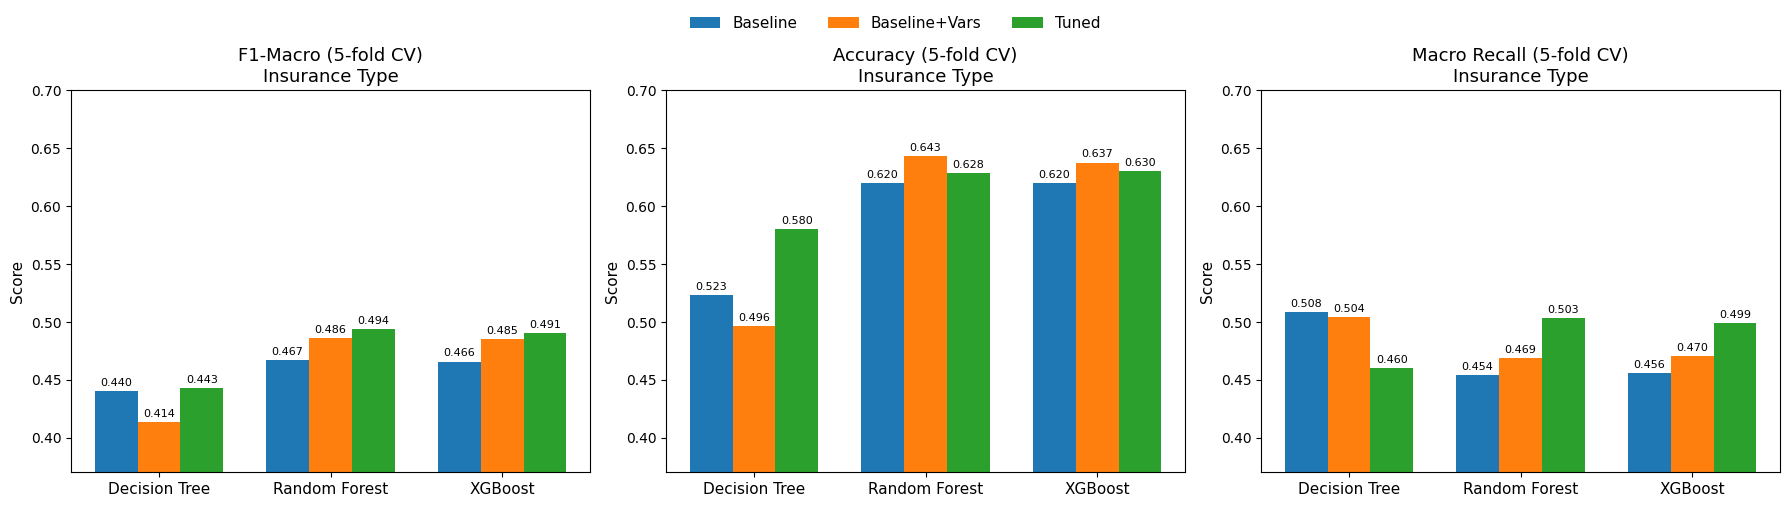

In [8]:
#Model Optimization and Comparison
import numpy as np
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest", "XGBoost"]
stages = ["Baseline", "Baseline+Vars", "Tuned"]

# F1-macro
f1 = np.array([
    [0.4401, 0.4136, 0.4426],
    [0.4666, 0.4859, 0.4940],
    [0.4656, 0.4853, 0.4906],
])

# Accuracy
acc = np.array([
    [0.5231, 0.4965, 0.5802],
    [0.6199, 0.6431, 0.6285],
    [0.6201, 0.6375, 0.6300],
])

# Macro Recall
rec = np.array([
    [0.5083, 0.5039, 0.4601],
    [0.4542, 0.4686, 0.5034],
    [0.4556, 0.4703, 0.4991],
])

def plot_grouped_subplot(ax, values, title, ylabel):
    x = np.arange(len(models))
    width = 0.25

    bars_all = []
    for i in range(3):
        bars = ax.bar(
            x + (i - 1) * width,
            values[:, i],
            width,
            label=stages[i]
        )
        bars_all.append(bars)

    ax.set_title(title + "\nInsurance Type", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.set_ylim(0.37, 0.70)

    for bars in bars_all:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.003,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    return bars_all

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars_f1 = plot_grouped_subplot(axes[0], f1, "F1-Macro (5-fold CV)", "Score")
bars_acc = plot_grouped_subplot(axes[1], acc, "Accuracy (5-fold CV)", "Score")
bars_rec = plot_grouped_subplot(axes[2], rec, "Macro Recall (5-fold CV)", "Score")

handles = [b[0] for b in bars_f1]
labels = stages

fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**Model Performance Summary (Insurance Type Classification)**  

- **F1-Macro** was selected as **the primary metric** for **hyperparameter tuning**, as it **balances precision and recall** across all classes.
- Adding new features have significant improvements on model performance for Random Forest and XGBoost.
- Across all three evaluation metrics, **Random Forest and XGBoost** consistently outperform the Decision Tree baseline. **Random Forest achieves the highest overall F1-macro** and shows **strong improvements in macro recall** when additional engineered variables are included. **XGBoost delivers similarly competitive performance** with stable gains after hyperparameter tuning, particularly in recall-oriented metrics, indicating better handling of class imbalance. **Decision Trees**, while interpretable, **lag behind in predictive performance** across all metrics.

- Overall, the results suggest that **ensemble methods (esp. Random Forest) provide a more robust and generalizable solution** for the **multi-class insurance prediction task**.


FINAL MODEL PERFORMANCE ON TEST SET (insurance_type)
              precision    recall  f1-score   support

        Both       0.52      0.66      0.58       257
Private only       0.73      0.84      0.78       584
 Public only       0.66      0.49      0.56       625
   Uninsured       0.38      0.40      0.39       141
     Unknown       0.33      0.29      0.31        24

    accuracy                           0.63      1631
   macro avg       0.52      0.54      0.53      1631
weighted avg       0.63      0.63      0.63      1631



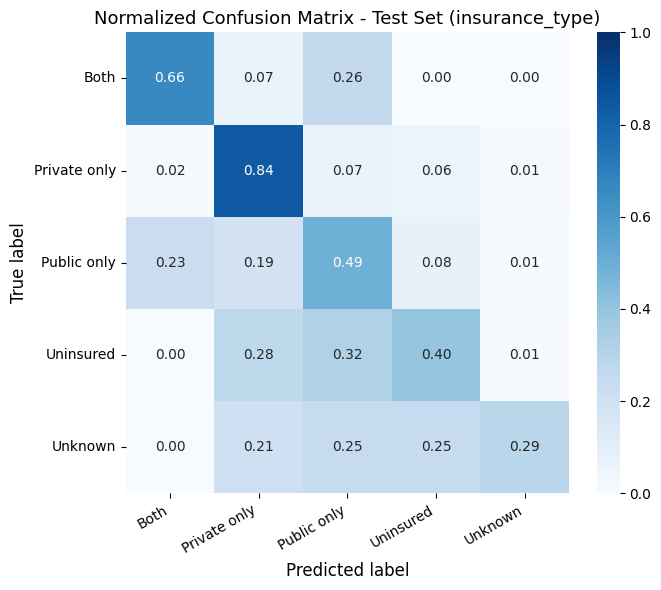

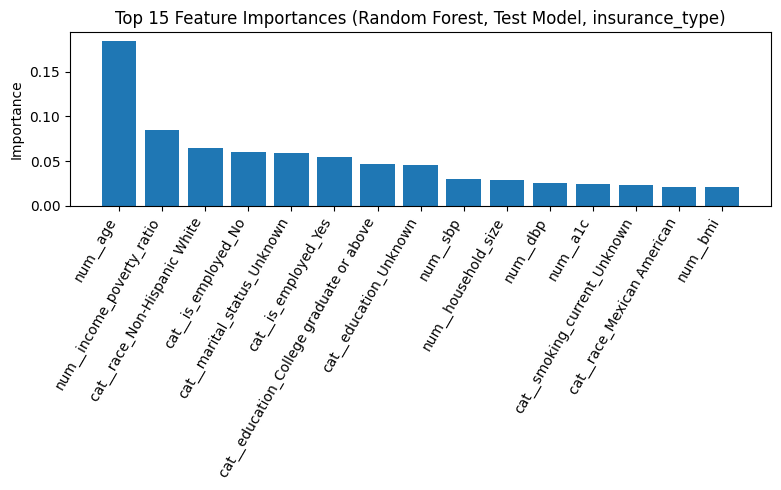

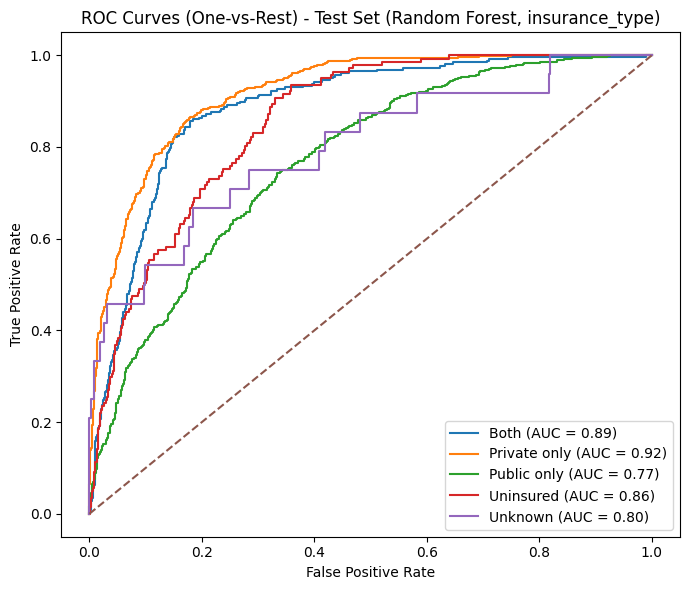

In [14]:
# Evaluate the model performance on test set
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
import seaborn as sns
from sklearn.preprocessing import label_binarize

final_model_ins = best_models_ins[best_model_name]

# Final model prediction (numbers)
y_ins_pred_test = final_model_ins.predict(X_ins_test)

# Convert back to original category names using LabelEncoder
y_test_named = le_ins.inverse_transform(y_ins_test)
y_pred_named = le_ins.inverse_transform(y_ins_pred_test)

# Final model prediction (numbers)
y_ins_pred_test = final_model_ins.predict(X_ins_test)

# Convert back to original category names using LabelEncoder
y_test_named = le_ins.inverse_transform(y_ins_test)
y_pred_named = le_ins.inverse_transform(y_ins_pred_test)

print("\nFINAL MODEL PERFORMANCE ON TEST SET (insurance_type)")
print(classification_report(y_test_named, y_pred_named))

# Confusion Matrix
cm_norm = confusion_matrix(
    y_ins_test,
    y_ins_pred_test,
    normalize="true"
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,            # show numbers inside cells
    fmt=".2f",             # keep two decimals
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0.0,
    vmax=1.0
)
plt.title("Normalized Confusion Matrix - Test Set (insurance_type)", fontsize=13)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrix_insurance_type.png", dpi=300, bbox_inches="tight")
plt.show()


# Feature Importance

preprocessor = final_model_ins.named_steps["preprocess"]
rf_clf = final_model_ins.named_steps["clf"]
feature_names = preprocessor.get_feature_names_out()

importances = rf_clf.feature_importances_

top_k = 15 # Top15 key features
indices = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(8, 5))
plt.bar(range(top_k), importances[indices])
plt.xticks(range(top_k), feature_names[indices], rotation=60, ha="right")
plt.ylabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest, Test Model, insurance_type)")
plt.tight_layout()
plt.show()


# 3. ROC Curves（One-vs-Rest for multiple categories）

n_classes = len(le_ins.classes_)

y_test_bin = label_binarize(y_ins_test, classes=np.arange(n_classes))

# shape: [n_samples, n_classes]
y_score = final_model_ins.predict_proba(X_ins_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 6))
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{le_ins.classes_[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - Test Set (Random Forest, insurance_type)")
plt.legend()
plt.tight_layout()
plt.show()

**1. Test Set Classification Report（precision/recall/F1）**

**Private-only is the best-predicted class** (F1 = 0.78), driven by clear employment and income signals.  
**Both (dual coverage) achieves moderate performance (F1 = 0.58)**, benefiting from distinguishable patterns among older groups but still **showing overlap with Public-only**.  
**Public-only is moderately predicted (F1 = 0.56)**, reflecting overlapping socioeconomic profiles with other groups.  
**Uninsured remains challenging (F1 = 0.39–0.31)**, indicating limited and noisy signal for these minority categories.  

**2. Confusion Matrix (Normalized)**

The model correctly **identifies the majority of Private-only (84%) and Both (66%) cases**, showing strong separation for insurance groups with distinct socioeconomic patterns.
**Most confusion occurs between Public-only vs. Both and Uninsured vs. Public-only**, reflecting real-world overlap in demographics and financial eligibility criteria.

**3. Feature Importance**

**Age and income–poverty ratio dominate prediction**, confirming **strong socioeconomic gradients** behind insurance type.  
**Race, employment, and education** collectively form **the next tier** of influential predictors, while **clinical measures (BP, A1C)** play a **smaller role**—highlighting that insurance coverage is driven much more by demographics than physiological health status.

**4. ROC Curves (One-vs-Rest AUC)**

**AUC scores are high for Private-only (0.92) and Both (0.89)**, showing excellent discriminative ability for the largest and most distinct groups.
**Lower AUC for Public-only (0.77)** reflects overlapping socioeconomic characteristics across public program users.
**Uninsured also performs well (AUC = 0.86)**.

## 4.2 Classification for Hypertension Risk Prediction
We define `hypertension_stage` from SBP/DBP into **Normal / Stage 1 / Stage 2**.

### 4.2.1 Baseline Models - Decision Tree, Random Forest, XGBoost

In [4]:
#Define Hypertension labels via the sbp and dbp
def classify_hypertension_stage(row):
    """
    Classify hypertension stage based on SBP/DBP.

    Returns:
        "Stage 2", "Stage 1", or "Normal"
        If sbp / dbp is missing, return None.
    """
    sbp = row["sbp"]
    dbp = row["dbp"]

    if pd.isna(sbp) or pd.isna(dbp):
        return None

    # Stage 2
    if sbp >= 140 or dbp >= 90:
        return "Stage 2"
    # Stage 1
    elif 130 <= sbp < 140 or 80 <= dbp < 90:
        return "Stage 1"
    # Normal + High-normal
    else:
        return "Normal"

# Create target column: hypertension_stage
nhanes_clean_adult_add["hypertension_stage"] = nhanes_clean_adult_add.apply(
    classify_hypertension_stage,
    axis=1
)

In [5]:
#ColumnTransformer + OnehotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Feature & target for hypertension
hyp_feature_cols = [
    "age",
    "gender",
    "race",
    "education",
    "income_poverty_ratio",
    "marital_status",
    "household_size",
    "is_employed",
    "smoking_current",
    "diabetes_self_report",
    "bmi",
    "a1c",
    "sleep_hours",
    "insurance_type",
]

target_hyp = "hypertension_stage"

categorical_hyp = [
    "gender", "race", "education", "marital_status",
    "is_employed", "smoking_current", "diabetes_self_report", "insurance_type",
]

numeric_hyp = [
    "age", "income_poverty_ratio", "household_size",
    "bmi", "a1c", "sleep_hours",
]

# ColumnTransformer + OneHot
preprocess_hyp = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_hyp),
        ("num", "passthrough", numeric_hyp),
    ]
)


In [6]:
#Train/Test Split + StratifiedKFold

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Build X, y and drop rows with missing features / target
X_hyp = nhanes_clean_adult_add[hyp_feature_cols].copy()
y_hyp = nhanes_clean_adult_add[target_hyp].copy()

data_hyp = (
    pd.concat([X_hyp, y_hyp], axis=1)
    .dropna(subset=hyp_feature_cols + [target_hyp])
)

X_hyp = data_hyp[hyp_feature_cols]
y_hyp = data_hyp[target_hyp]

# LabelEncode target: string → integer
le_hyp = LabelEncoder()
y_hyp_encoded = le_hyp.fit_transform(y_hyp)

# IDs of Stage 1 & Stage 2 after label encoding
stage_labels = le_hyp.transform(["Stage 1", "Stage 2"])

# Train/Test split
X_hyp_train, X_hyp_test, y_hyp_train, y_hyp_test = train_test_split(
    X_hyp,
    y_hyp_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_hyp_encoded,
)

# Stratified K-Fold (CV)
cv_hyp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [7]:
# Baseline models for hypertension and GridSearchCV for hypertension optimization
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import make_scorer, recall_score

stage_labels = le_hyp.transform(["Stage 1", "Stage 2"])

def stage12_recall(y_true, y_pred):
    """
    Custom metric:
    average recall over Stage 1 and Stage 2 (ignore 'Normal').
    """
    recs = recall_score(
        y_true,
        y_pred,
        labels=stage_labels,   # only Stage 1 & Stage 2
        average=None,
        zero_division=0,
    )
    return recs.mean()

stage12_recall_scorer = make_scorer(stage12_recall)

#Baselin CV scoring
scoring_cv_hyp = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "recall_weighted": "recall_weighted",
    "f1_macro": "f1_macro",
    "stage12_recall": stage12_recall_scorer,  # NEW: focus on Stage 1 & 2
}

models_hyp = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        min_samples_split=50,
        min_samples_leaf=10,
        random_state=42,
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=2,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
    ),
}

print("BASELINE CV PERFORMANCE (hypertension_stage)")
baseline_scores_hyp = {}

for name, clf in models_hyp.items():
    pipe = Pipeline([
        ("preprocess", preprocess_hyp),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf),
    ])

    cv_res = cross_validate(
        pipe,
        X_hyp_train,
        y_hyp_train,
        cv=cv_hyp,
        scoring=scoring_cv_hyp,
        n_jobs=2,
        return_train_score=False,
    )

    acc_mean   = cv_res["test_accuracy"].mean()
    rec_mean   = cv_res["test_recall_macro"].mean()
    f1_mean    = cv_res["test_f1_macro"].mean()
    st12_mean  = cv_res["test_stage12_recall"].mean()  # NEW

    baseline_scores_hyp[name] = {
        "accuracy_cv": acc_mean,
        "recall_macro_cv": rec_mean,
        "f1_macro_cv": f1_mean,
        "stage12_recall_cv": st12_mean,   # NEW
    }

    print(f"\nHypertension {name} (baseline, all vars)")
    print("5-fold Accuracy per fold:", cv_res["test_accuracy"])
    print("5-fold Macro Recall per fold:", cv_res["test_recall_macro"])
    print("5-fold F1-macro per fold:", cv_res["test_f1_macro"])
    print("5-fold Stage1+2 Recall per fold:", cv_res["test_stage12_recall"])  # NEW
    print("Mean Accuracy:", acc_mean)
    print("Mean Macro Recall:", rec_mean)
    print("Mean F1-macro:", f1_mean)
    print("Mean Stage1+2 Recall:", st12_mean)

# GridSearch with Stage1+2 Recall as main metric
param_grids_hyp = {
    "Decision_Tree": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [3, 5, 10, None],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "Random_Forest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5],
        "clf__max_features": ["sqrt", "log2"],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
    },
}

scoring_multi_hyp = {
    "stage12_recall": stage12_recall_scorer,  # MAIN metric
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "accuracy": "accuracy",
}

best_models_hyp = {}
tuned_scores_hyp = {}

print("\n\nGRIDSEARCH WITH STAGE1+2 RECALL (hypertension_stage)")

for name in ["Decision_Tree", "Random_Forest", "XGBoost"]:
    print(f"\n----- GridSearch for {name} on hypertension_stage (Stage1+2 Recall as main metric) -----")

    base_clf = models_hyp[name]

    pipe = Pipeline([
        ("preprocess", preprocess_hyp),
        ("smote", SMOTE(random_state=42)),
        ("clf", base_clf),
    ])

    grid = param_grids_hyp[name]

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=cv_hyp,
        scoring=scoring_multi_hyp,
        refit="stage12_recall",   # <<< use Stage1+2 Recall to refit best model
        n_jobs=2,
    )

    gs.fit(X_hyp_train, y_hyp_train)

    best_models_hyp[name] = gs.best_estimator_

    cv_results = gs.cv_results_
    best_idx = gs.best_index_

    best_stage12 = cv_results["mean_test_stage12_recall"][best_idx]
    best_rec     = cv_results["mean_test_recall_macro"][best_idx]
    best_f1      = cv_results["mean_test_f1_macro"][best_idx]
    best_acc     = cv_results["mean_test_accuracy"][best_idx]

    tuned_scores_hyp[name] = {
        "stage12_recall_cv": best_stage12,
        "recall_macro_cv": best_rec,
        "f1_macro_cv": best_f1,
        "accuracy_cv": best_acc,
        "best_params": gs.best_params_,
    }

    print("Best params:", gs.best_params_)
    print(f"Best CV Stage1+2 Recall: {best_stage12:.4f}  (main metric)")
    print(f"Best CV Macro Recall:    {best_rec:.4f}")
    print(f"Best CV F1-macro:        {best_f1:.4f}")
    print(f"Best CV Accuracy:        {best_acc:.4f}")

print("\n\nSUMMARY: TUNED MODELS (CV, hypertension_stage)")
for name, metrics in tuned_scores_hyp.items():
    print(f"\n>>> {name}")
    print(f"  Accuracy (CV, tuned):        {metrics['accuracy_cv']:.4f}")
    print(f"  Macro Recall (CV, tuned):    {metrics['recall_macro_cv']:.4f}")
    print(f"  F1-macro (CV, tuned):        {metrics['f1_macro_cv']:.4f}")
    print(f"  Stage1+2 Recall (CV, tuned): {metrics['stage12_recall_cv']:.4f}")
    print(f"  Best Params: {metrics['best_params']}")

best_model_name_hyp = max(
    tuned_scores_hyp,
    key=lambda m: tuned_scores_hyp[m]["stage12_recall_cv"],
)

print(f"\n***** Best model by CV Stage1+2 Recall (hypertension_stage): {best_model_name_hyp} *****")
print("With scores:", tuned_scores_hyp[best_model_name_hyp])

final_model_hyp = best_models_hyp[best_model_name_hyp]


BASELINE CV PERFORMANCE (hypertension_stage)

Hypertension Decision_Tree (baseline, all vars)
5-fold Accuracy per fold: [0.548659   0.5394636  0.54754601 0.54064417 0.56211656]
5-fold Macro Recall per fold: [0.49253969 0.44969832 0.44942685 0.49580191 0.48925088]
5-fold F1-macro per fold: [0.44664869 0.39117773 0.42600758 0.45511193 0.44862064]
5-fold Stage1+2 Recall per fold: [0.43428975 0.35646839 0.35230769 0.45128205 0.41487179]
Mean Accuracy: 0.5476858707660484
Mean Macro Recall: 0.47534352927670903
Mean F1-macro: 0.4335133156161036
Mean Stage1+2 Recall: 0.4018439361933569

Hypertension Random_Forest (baseline, all vars)
5-fold Accuracy per fold: [0.65210728 0.65747126 0.66411043 0.66717791 0.66794479]
5-fold Macro Recall per fold: [0.36908089 0.38110838 0.37466734 0.39011228 0.38626445]
5-fold F1-macro per fold: [0.35858036 0.37587179 0.36041859 0.3858979  0.38124309]
5-fold Stage1+2 Recall per fold: [0.09542925 0.11347049 0.09367521 0.12136752 0.11333333]
Mean Accuracy: 0.661762

/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV Stage1+2 Recall: 0.1454  (main metric)
Best CV Macro Recall:    0.3978
Best CV F1-macro:        0.3960
Best CV Accuracy:        0.6578

----- GridSearch for XGBoost on hypertension_stage (Stage1+2 Recall as main metric) -----
Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 300, 'clf__subsample': 1.0}
Best CV Stage1+2 Recall: 0.1583  (main metric)
Best CV Macro Recall:    0.4014
Best CV F1-macro:        0.4034
Best CV Accuracy:        0.6523


SUMMARY: TUNED MODELS (CV, hypertension_stage)

>>> Decision_Tree
  Accuracy (CV, tuned):        0.5638
  Macro Recall (CV, tuned):    0.5044
  F1-macro (CV, tuned):        0.4681
  Stage1+2 Recall (CV, tuned): 0.4465
  Best Params: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10}

>>> Random_Forest
  Accuracy (CV, tuned):        

### 4.2.2 Model Comparison, Selection and Final Model Evaluation¶

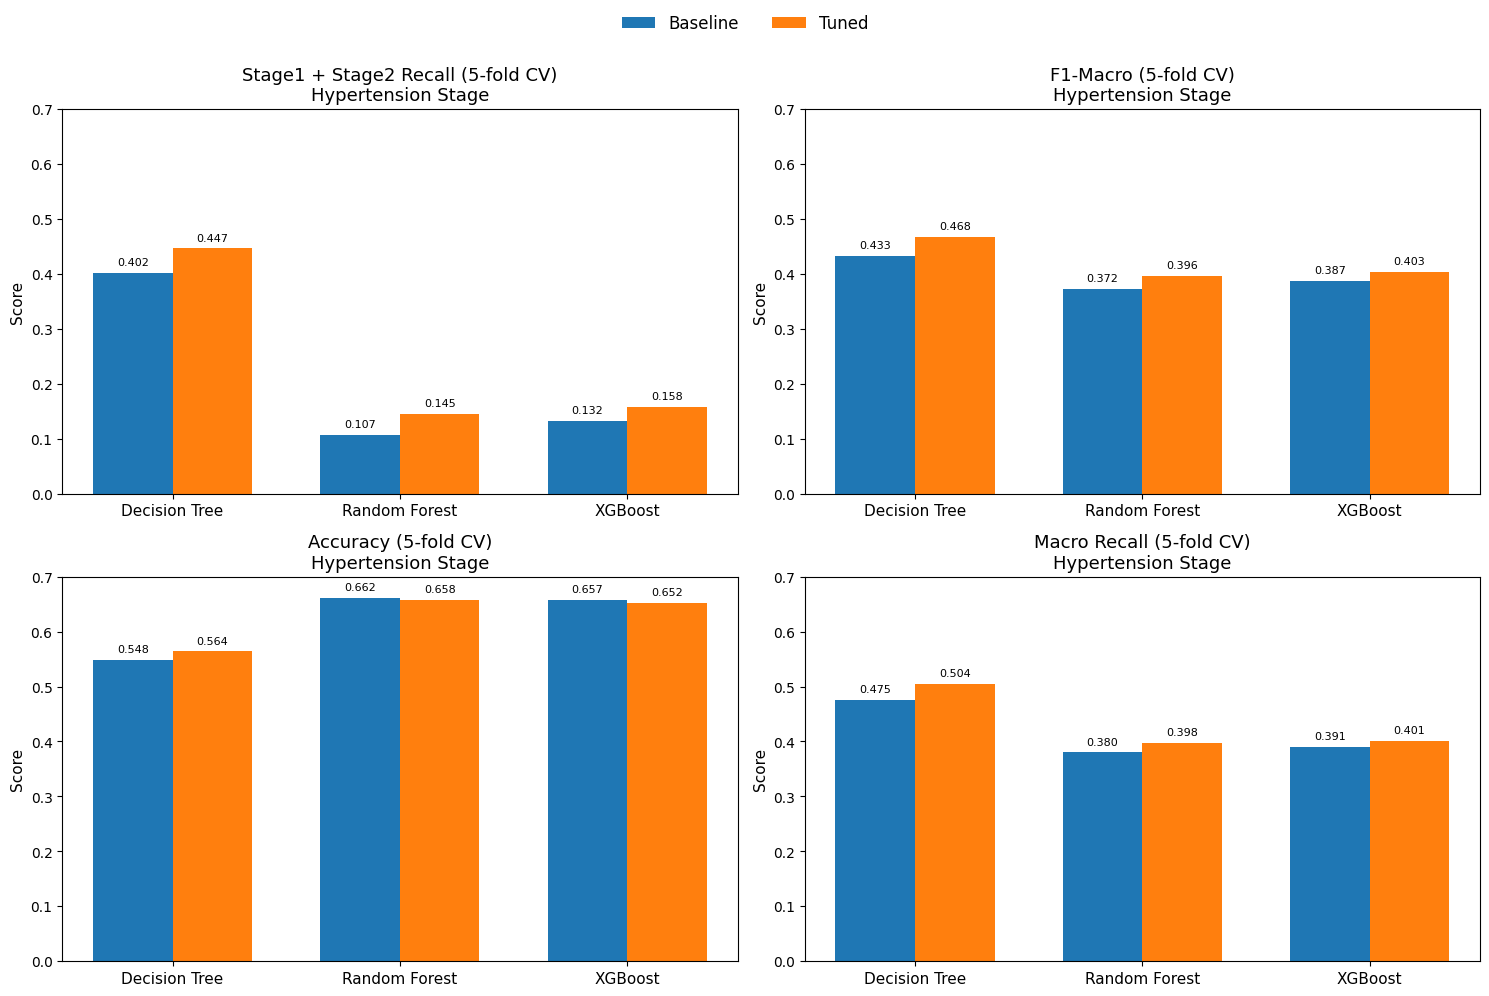

In [12]:
#Model Optimization and Comparison
import numpy as np
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest", "XGBoost"]
stages = ["Baseline", "Tuned"]


# Stage1 + Stage2 Recall (最重要)
rec12 = np.array([
    [0.4018, 0.4465],   # Decision Tree
    [0.1075, 0.1454],   # Random Forest
    [0.1321, 0.1583],   # XGBoost
])

# F1-macro
f1 = np.array([
    [0.4335, 0.4681],   # Decision Tree
    [0.3724, 0.3960],   # Random Forest
    [0.3868, 0.4034],   # XGBoost
])

# Accuracy
acc = np.array([
    [0.5477, 0.5638],   # Decision Tree
    [0.6618, 0.6578],   # Random Forest
    [0.6570, 0.6523],   # XGBoost
])

# Macro Recall
rec = np.array([
    [0.4753, 0.5044],   # Decision Tree
    [0.3802, 0.3978],   # Random Forest
    [0.3906, 0.4014],   # XGBoost
])


def plot_metric(ax, values, title):
    """
    ax:      matplotlib Axes
    values:  shape = (3 models, 2 stages)
    title:   subplot title
    """
    x = np.arange(len(models))
    width = 0.35   # two bars per group

    # bars
    for i in range(2):   # 0: Baseline, 1: Tuned
        ax.bar(
            x + (i - 0.5) * width,
            values[:, i],
            width,
            label=stages[i]
        )

    # title & axes
    ax.set_title(title + "\nHypertension Stage", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("Score", fontsize=11)

    # y-axis range
    ax.set_ylim(0.0, 0.7)

    # value labels
    for i in range(2):
        for j in range(len(models)):
            h = values[j, i]
            ax.text(
                x[j] + (i - 0.5) * width,
                h + 0.01,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )



fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Stage1+2 Recall, F1-macro
plot_metric(axes[0, 0], rec12, "Stage1 + Stage2 Recall (5-fold CV)")
plot_metric(axes[0, 1], f1, "F1-Macro (5-fold CV)")

# Accuracy, Macro Recall
plot_metric(axes[1, 0], acc, "Accuracy (5-fold CV)")
plot_metric(axes[1, 1], rec, "Macro Recall (5-fold CV)")

fig.legend(
    stages,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("model_comparison_hypertension.png", dpi=300, bbox_inches="tight")
plt.show()



**Model Comparison Summary (Hypertension Stage Classification)**

**Detecting Stage1 and Stage2 is our No.1 priority**. Based on this, a new metric - **Stage1 + Stage 2 Average Recall is defined as the primary metric for hyperparameter tuning**for hypetension stage prediction.  
Across all four evaluation metrics, **tuned models consistently outperform or match the baseline**, though the magnitude of improvement varies by algorithm and metric.  
**Stage 1 + Stage 2 Recall**: Tuning yields **the most noticeable gains** here.Tuning helps the models better **capture hypertensive individuals**, reducing false negatives.  
**F1-Macro**: All models show moderate improvements after tuning. **Balanced gains in precision and recall across classes**.  
**Accuracy**: Accuracy remains **relatively stable**. Overall correctness is already high; **tuning mainly affects minority class performance** rather than total accuracy.
**Macro Recall**: Tuning provides consistent but **modest improvements**. Better recovery of underrepresented classes after tuning.

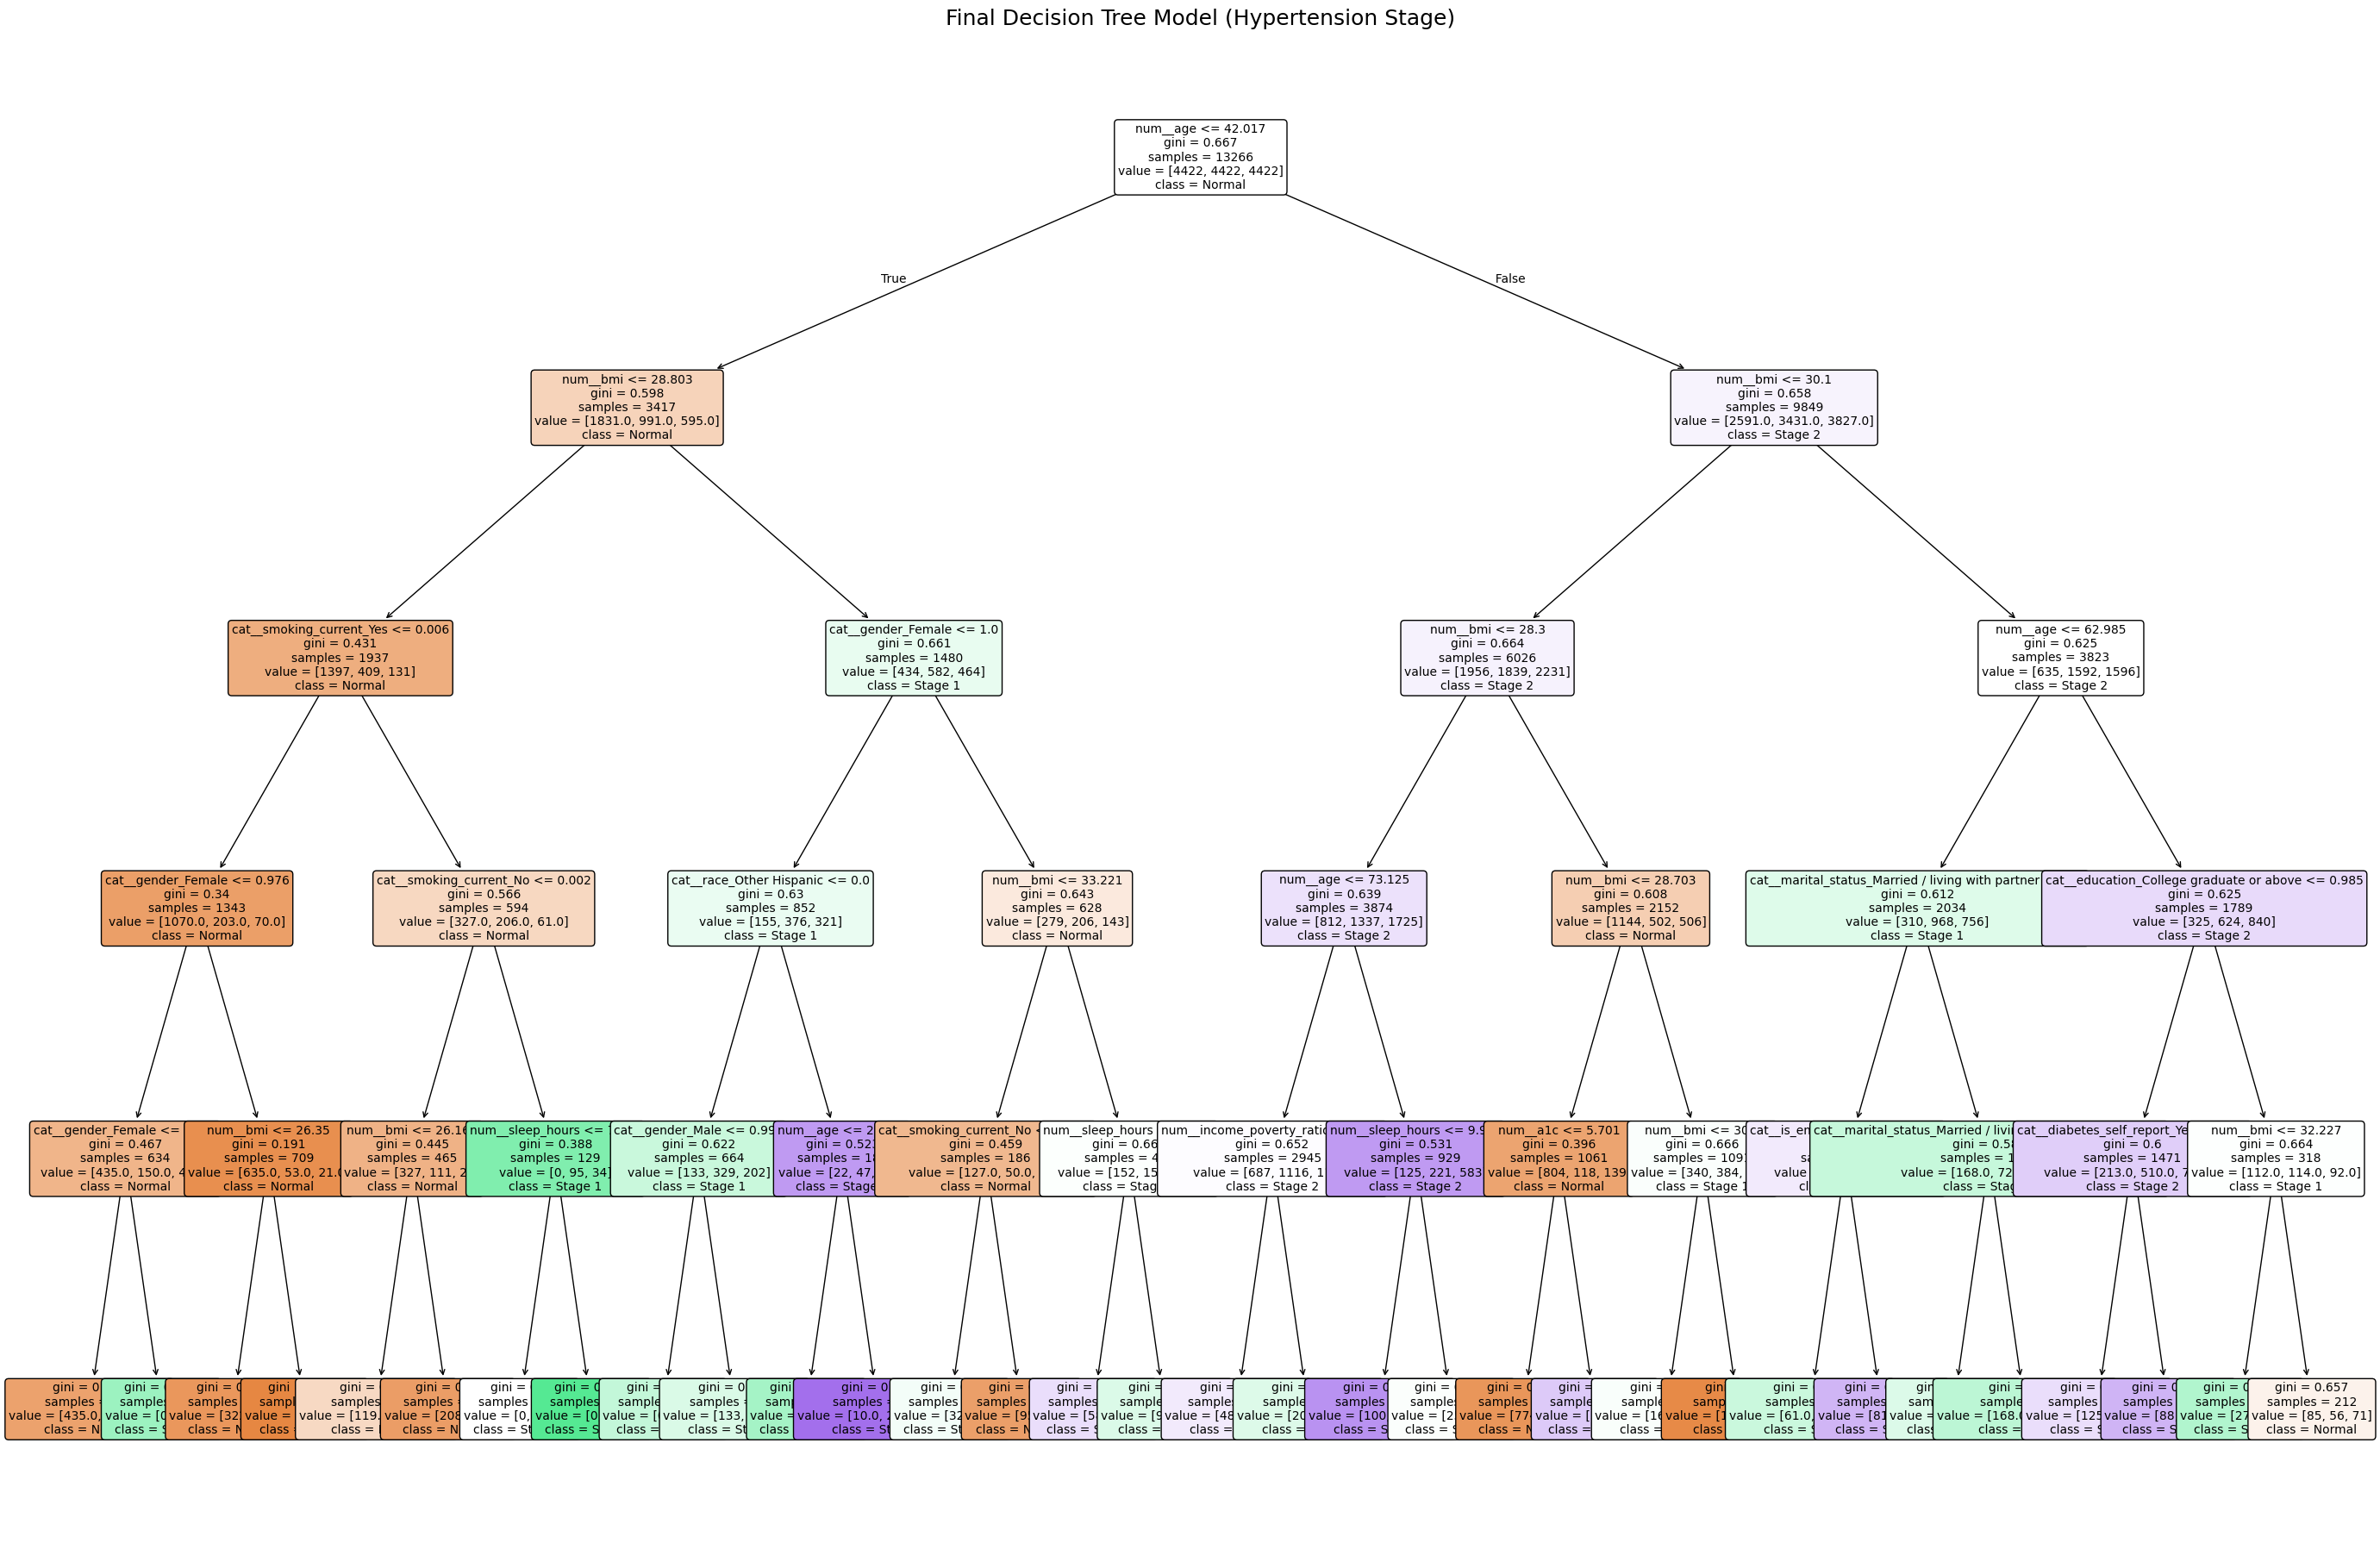

In [8]:
#Decision Tree visualization

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_tree = final_model_hyp.named_steps["clf"]

plt.figure(figsize=(28, 18))
plot_tree(
    best_tree,
    feature_names=final_model_hyp.named_steps["preprocess"]
                    .get_feature_names_out(),
    class_names=le_hyp.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Final Decision Tree Model (Hypertension Stage)", fontsize=18)
plt.tight_layout()
plt.savefig("Final Decision Tree Model (Hypertension Stage).png", dpi=300, bbox_inches="tight")
plt.show()

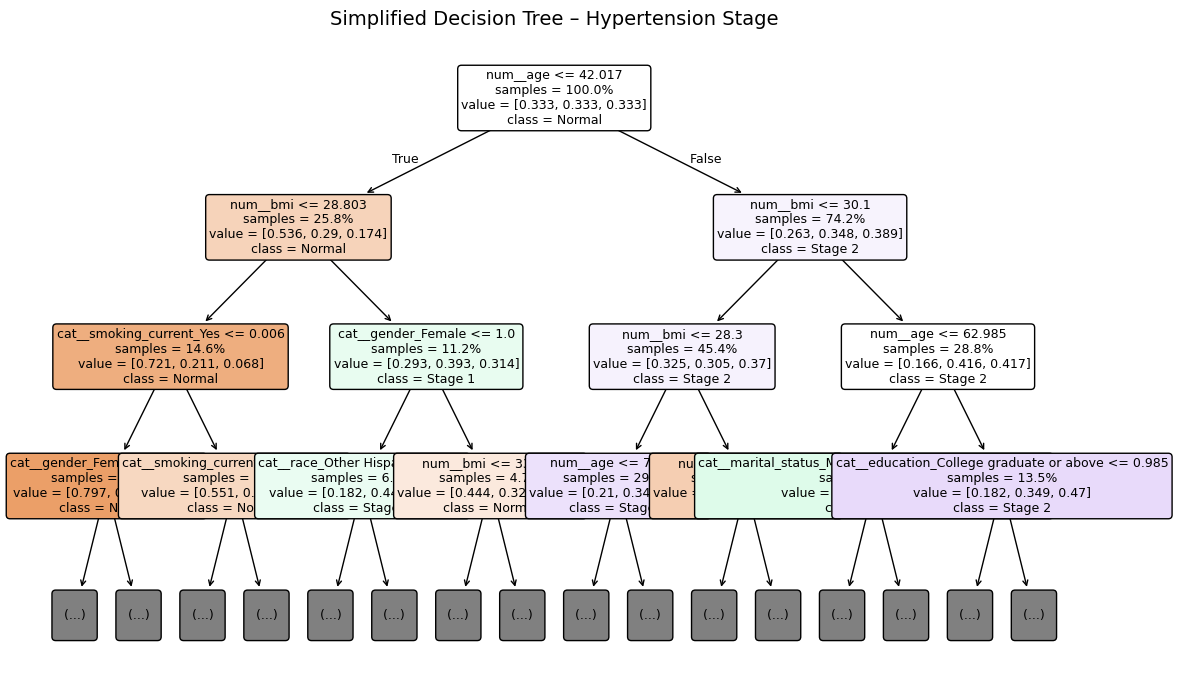

In [21]:
# Simplified Decision Tree Visualization for Presentation (max_depth=3)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_clf = final_model_hyp.named_steps["clf"]

feature_names = final_model_hyp.named_steps["preprocess"].get_feature_names_out()

class_names = le_hyp.classes_

plt.figure(figsize=(12, 7))

plot_tree(
    tree_clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,          
    rounded=True,         
    max_depth=3,          
    impurity=False,       
    proportion=True,      
    fontsize=9
)

plt.title("Simplified Decision Tree – Hypertension Stage", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree_hyp_simplified.png", dpi=300, bbox_inches="tight")
plt.show()



FINAL MODEL PERFORMANCE ON TEST SET (hypertension_stage)
              precision    recall  f1-score   support

      Normal       0.88      0.54      0.67      1106
     Stage 1       0.25      0.38      0.30       282
     Stage 2       0.26      0.57      0.36       243

    accuracy                           0.52      1631
   macro avg       0.47      0.50      0.44      1631
weighted avg       0.68      0.52      0.56      1631



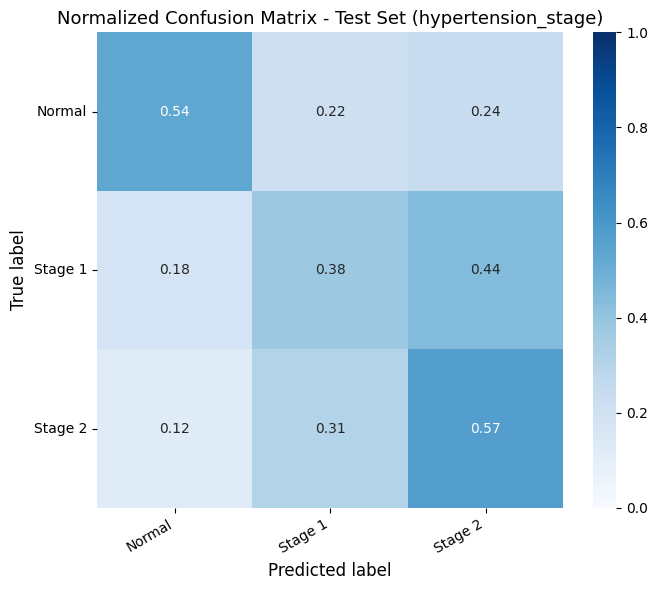

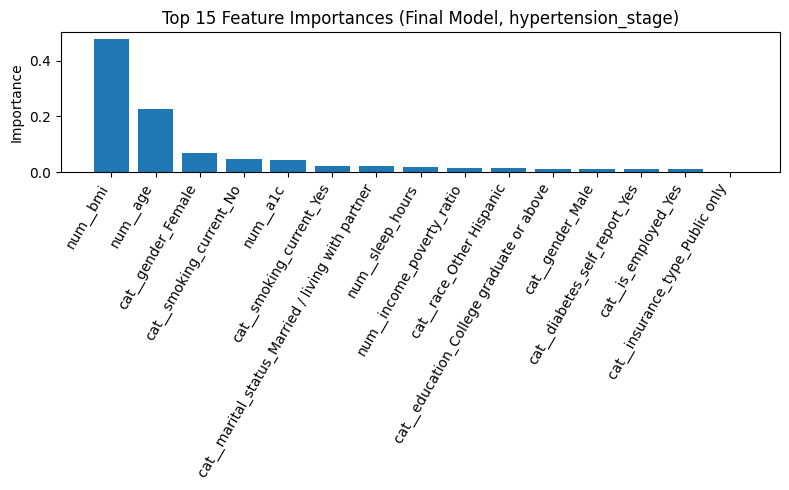

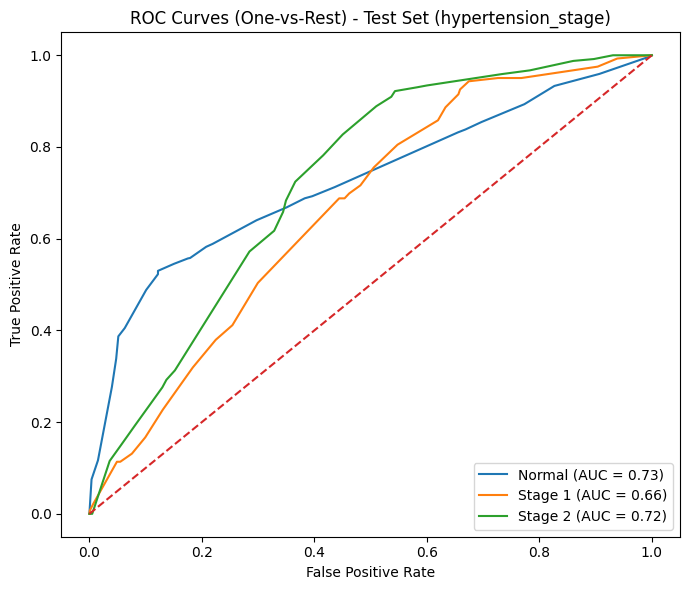

In [55]:
# Evaluate final hypertension moddel on test set

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Final model
final_model_hyp = best_models_hyp[best_model_name_hyp]

#Test prediction
y_hyp_pred_test = final_model_hyp.predict(X_hyp_test)

y_test_named_hyp = le_hyp.inverse_transform(y_hyp_test)
y_pred_named_hyp = le_hyp.inverse_transform(y_hyp_pred_test)

print("\nFINAL MODEL PERFORMANCE ON TEST SET (hypertension_stage)")
print(classification_report(y_test_named_hyp, y_pred_named_hyp))

# Confusion Matrix
cm_norm_hyp = confusion_matrix(
    y_hyp_test,
    y_hyp_pred_test,
    normalize="true"
)

class_names_hyp = le_hyp.classes_   # ["Normal", "Stage 1", "Stage 2"]

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm_hyp,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names_hyp,
    yticklabels=class_names_hyp,
    vmin=0.0,
    vmax=1.0
)
plt.title("Normalized Confusion Matrix - Test Set (hypertension_stage)", fontsize=13)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrix_hypertension_stage.png", dpi=300, bbox_inches="tight")
plt.show()


# Feature Importance (Top 15)
preprocessor_hyp = final_model_hyp.named_steps["preprocess"]
clf_hyp = final_model_hyp.named_steps["clf"]

feature_names_hyp = preprocessor_hyp.get_feature_names_out()
importances_hyp = clf_hyp.feature_importances_

top_k = 15
indices_hyp = np.argsort(importances_hyp)[::-1][:top_k]

plt.figure(figsize=(8, 5))
plt.bar(range(top_k), importances_hyp[indices_hyp])
plt.xticks(range(top_k), feature_names_hyp[indices_hyp], rotation=60, ha="right")
plt.ylabel("Importance")
plt.title("Top 15 Feature Importances (Final Model, hypertension_stage)")
plt.tight_layout()
plt.savefig("feature_importance_hypertension_stage.png", dpi=300, bbox_inches="tight")
plt.show()


# ROC Curves（One-vs-Rest，Multiple categories）
n_classes_hyp = len(le_hyp.classes_)

y_test_bin_hyp = label_binarize(y_hyp_test, classes=np.arange(n_classes_hyp))

y_score_hyp = final_model_hyp.predict_proba(X_hyp_test)

fpr_hyp = {}
tpr_hyp = {}
roc_auc_hyp = {}

for i in range(n_classes_hyp):
    fpr_hyp[i], tpr_hyp[i], _ = roc_curve(y_test_bin_hyp[:, i], y_score_hyp[:, i])
    roc_auc_hyp[i] = auc(fpr_hyp[i], tpr_hyp[i])

plt.figure(figsize=(7, 6))
for i in range(n_classes_hyp):
    plt.plot(
        fpr_hyp[i],
        tpr_hyp[i],
        label=f"{le_hyp.classes_[i]} (AUC = {roc_auc_hyp[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - Test Set (hypertension_stage)")
plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)
plt.tight_layout()
plt.savefig("roc_curves_hypertension_stage.png", dpi=300, bbox_inches="tight")
plt.show()

**1. Test Set Classification Report (precision / recall / F1**  

Because hypertension prediction is **a clinical risk-screening task**, **recall is the key evaluation metric**, as failing to **identify hypertensive individuals (false negatives)** is more harmful than flagging borderline cases.  
**Stage 2** achieves the highest recall (0.57), indicating that the model is comparatively effective at **detecting severe hypertension**, which aligns with clearer **physiological patterns** (older age, higher BMI).  
**Stage 1**, however, has substantially lower recall (0.38), reflecting its **clinical ambiguity—Stage 1 individuals overlap strongly with Normal and Stage 2 groups** in BMI, age, and lifestyle factors, making them **the most difficult class to recover**.    
**The Normal class** achieves moderate recall (0.54) but benefits from **its large representation** in the dataset, which stabilizes its classification performance.    

**2. Confusion Matrix (Normalized)**

The model correctly identifies **54% of Normal cases**, but also **misclassifies 22% as Stage 1 and 24% as Stage 2**.
**Stage 2 is recovered relatively well (57% recall)**, showing the model captures the more severe hypertension patterns.
**Stage 1 exhibits the most confusion**:
- **38% correctly predicted**,
- 18% misclassified as Normal,
- **44% predicted as Stage 2**.
This pattern reflects early-stage hypertension is harder to separate from Normal and Stage 2 groups based on current variables.

**3. Top Feature Importances**

**BMI and Age overwhelmingly dominate prediction**, confirming strong epidemiological associations with hypertension risk.  
**Behavioral and metabolic factors** such as **current smoking, A1C, and sleep hours** contribute **additional predictive signal**.  
**Socioeconomic variables (education, income-poverty ratio, employment)** appear but play a **secondary role** compared to direct physiological indicators.  
Insurance type alone contributes minimally, showing that hypertension status is **primarily clinically driven**, **not demographically driven**.  

**4. ROC Curves (One-vs-Rest AUC)**

The model demonstrates relatively **strong discriminative ability for Normal (AUC = 0.73) and Stage 2 (AUC = 0.72)**.  
**Stage 1 has a lower AUC (0.66)**, consistent with **its intermediate nature and overlap with both adjacent classes**.  
This pattern reflects **real-world difficulty**: **mild hypertension is the hardest to clinically identify**, whereas severe hypertension exhibits clearer physiological separation.  